# Biodiversity Forecasting for Frontend: Aggregated Trend + Country Breakdown

This notebook creates a **product-oriented forecasting workflow** with two complementary views:

1. **Aggregated species-level trend** for a clean main chart  
2. **Country-level breakdown** for drill-down analysis  

It also includes **clean uncertainty bands** that widen with forecast horizon.

## Product logic

When a user searches a species:

- the frontend can show **one aggregated line** as the primary view
- it can also show a **country breakdown** as a secondary view
- both outputs are returned in a frontend-friendly structure

## Modeling logic

This notebook uses:
- a **global Random Forest model**
- lag and trend features
- direct multi-step models for:
  - t+3
  - t+5
  - t+10
  - t+15
  - t+20

For uncertainty, the notebook uses **horizon-specific residual distributions** and then smooths the resulting intervals so that the uncertainty bands widen cleanly with forecast horizon.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 2. Load data

In [2]:
DATA_PATH = Path("../data/interim/strict_forecasting/lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv")
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(49, 126)


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,...,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group
0,27563,Gulo_gulo,0,1,"Kojola, I., S. Heikkinen, S. Mäntyniemi and T....",Mammalia,Carnivora,Mustelidae,Gulo,gulo,...,True,True,True,True,True,True,True,direct_count,True,terrestrial
1,27564,Gulo_gulo,0,1,"Kojola, I., S. Heikkinen, S. Mäntyniemi and T....",Mammalia,Carnivora,Mustelidae,Gulo,gulo,...,True,True,True,True,True,True,True,direct_count,True,terrestrial
2,27565,Gulo_gulo,0,1,"Mattisson, J., L. Höglund and H. Brøseth (2020...",Mammalia,Carnivora,Mustelidae,Gulo,gulo,...,True,True,True,True,True,True,True,direct_count,True,terrestrial
3,27566,Gulo_gulo,0,1,"Mattisson, J., L. Höglund and H. Brøseth (2020...",Mammalia,Carnivora,Mustelidae,Gulo,gulo,...,True,True,True,True,True,True,True,direct_count,True,terrestrial
4,27730,Alces_americanus,0,1,Kluane National Park (2017) ‘Moose Survey Coun...,Mammalia,Artiodactyla,Cervidae,Alces,americanus,...,True,True,True,True,True,True,True,direct_count,True,terrestrial


## 3. Helper functions for preparation

This section defines the reusable functions that turn the raw LPD table into modeling-ready time series. It creates identifiers, reshapes the data from wide to long format, engineers lag-based features, constructs direct multi-horizon targets, computes evaluation metrics, and prepares two views of the data: a species-level aggregate for the main product chart and a country-level aggregate for drill-downs.

The country view is aggregated to **one clean country time series per species and year** before lags are created. This avoids interleaving several local populations from the same country into one artificial zig-zag series, which was the case in previous iterations.

In [3]:
reference_columns = list(df.columns)
year_columns = [col for col in reference_columns if str(col).isdigit()]

static_numeric_features = ["latitude", "longitude"]
static_categorical_features = [
    "class", "family", "ipbes_subregion", "system_group", "t_realm", "t_biome", "units"
]
identifier_columns = ["id", "binomial", "common_name", "location", "country"]

ref_set = set(reference_columns)
static_numeric_features = [c for c in static_numeric_features if c in ref_set]
static_categorical_features = [c for c in static_categorical_features if c in ref_set]
identifier_columns = [c for c in identifier_columns if c in ref_set]


def build_series_id(df, level="country"):
    """
    Build a stable time-series identifier.

    Levels:
    - species: one identifier per species
    - country: one identifier per species-country series
    - population: one identifier per underlying monitored population/site series
    """
    parts = []

    if "common_name" in df.columns:
        parts.append(df["common_name"].astype(str))
    elif "binomial" in df.columns:
        parts.append(df["binomial"].astype(str))

    if level in {"country", "population"} and "country" in df.columns:
        parts.append(df["country"].astype(str))

    if level == "population":
        population_parts = []
        for col in ["location", "id"]:
            if col in df.columns:
                population_parts.append(df[col].astype(str))

        if population_parts:
            pop_id = population_parts[0]
            for p in population_parts[1:]:
                pop_id = pop_id + "|" + p
            parts.append(pop_id)

    if not parts:
        return pd.Series(np.arange(len(df)).astype(str), index=df.index)

    series_id = parts[0]
    for p in parts[1:]:
        series_id = series_id + "|" + p

    return series_id


def wide_to_long(df):
    """
    Convert wide yearly population data into long format.
    """
    id_columns = [col for col in df.columns if col not in year_columns]

    long_df = df.melt(
        id_vars=id_columns,
        value_vars=year_columns,
        var_name="Year",
        value_name="Population"
    ).dropna(subset=["Population"]).copy()

    long_df["Year"] = long_df["Year"].astype(int)
    long_df["series_id_population"] = build_series_id(long_df, level="population")
    long_df["series_id_country"] = build_series_id(long_df, level="country")
    long_df["series_id_species"] = build_series_id(long_df, level="species")
    long_df["log_population"] = np.log1p(long_df["Population"])

    return long_df


def add_relative_population_index(long_df):
    """
    Create a within-population relative index (first observed value = 100).

    This remains optional in this notebook, but if relative aggregation is tested,
    the baseline should be set on the true monitored population series rather than
    on the already-aggregated country series.
    """
    out = long_df.sort_values(["series_id_population", "Year"]).copy()
    baseline = (
        out.groupby("series_id_population")["Population"]
        .transform("first")
        .replace(0, np.nan)
    )
    out["relative_population_index"] = (out["Population"] / baseline) * 100.0
    return out


def add_lag_features(long_df, series_id_col, n_lags=4):
    """
    Add lag, rolling, and change-based features for a chosen series identifier.
    """
    long_df = long_df.sort_values([series_id_col, "Year"]).copy()
    grouped_pop = long_df.groupby(series_id_col)["Population"]

    for lag in range(1, n_lags + 1):
        long_df[f"lag_{lag}"] = grouped_pop.shift(lag)

    long_df["prev_year"] = long_df.groupby(series_id_col)["Year"].shift(1)
    long_df["year_gap_from_prev"] = long_df["Year"] - long_df["prev_year"]

    lagged_pop = grouped_pop.shift(1)
    long_df["rolling_mean_3"] = (
        lagged_pop.groupby(long_df[series_id_col]).rolling(3).mean().reset_index(level=0, drop=True)
    )
    long_df["rolling_std_3"] = (
        lagged_pop.groupby(long_df[series_id_col]).rolling(3).std().reset_index(level=0, drop=True)
    )

    long_df["population_difference"] = long_df["lag_1"] - long_df["lag_2"]
    long_df["population_growth_rate"] = (
        (long_df["lag_1"] - long_df["lag_2"]) / long_df["lag_2"].replace(0, np.nan)
    ).replace([np.inf, -np.inf], np.nan)

    needed = [f"lag_{lag}" for lag in range(1, n_lags + 1)]
    long_df = long_df.dropna(subset=needed).copy()

    return long_df


def create_direct_horizon_dataset(df, series_id_col, horizon):
    """
    Create a direct multi-step forecasting dataset for a fixed year-based horizon.
    """
    future_df = df[[series_id_col, "Year", "log_population", "Population"]].copy()
    future_df = future_df.rename(columns={
        series_id_col: "series_key",
        "Year": "target_year",
        "log_population": f"target_log_t_plus_{horizon}",
        "Population": f"target_population_t_plus_{horizon}"
    })

    out = df.copy()
    out["series_key"] = out[series_id_col]
    out["target_year"] = out["Year"] + horizon

    out = out.merge(
        future_df,
        on=["series_key", "target_year"],
        how="inner"
    )

    return out


def temporal_split(df, test_years=5, year_col="Year"):
    """
    Split a dataset into train and test sets based on the most recent years.
    """
    years = sorted(df[year_col].unique())
    test_year_values = years[-test_years:]

    train_df = df[df[year_col] < min(test_year_values)].copy().reset_index(drop=True)
    test_df = df[df[year_col].isin(test_year_values)].copy().reset_index(drop=True)

    return train_df, test_df, test_year_values


def evaluate(y_true, y_pred):
    """
    Compute evaluation metrics on the original population scale.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mean_abs_true = np.mean(np.abs(y_true))
    nmae = mae / mean_abs_true if mean_abs_true != 0 else np.nan

    denom = np.sum(np.abs(y_true))
    wape = np.sum(np.abs(y_true - y_pred)) / denom if denom != 0 else np.nan

    smape_denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = smape_denom != 0
    smape = (
        np.mean(np.abs(y_true[valid] - y_pred[valid]) / smape_denom[valid])
        if np.any(valid) else np.nan
    )

    return {"MAE": mae, "RMSE": rmse, "NMAE": nmae, "WAPE": wape, "sMAPE": smape}


def prepare_country_df(long_df, n_lags=4):
    """
    Prepare the country-level modeling dataframe using raw population values.

    Important design choice:
    the LPD can contain multiple monitored populations within the same country.
    To obtain one interpretable country time series, this function first aggregates
    all monitored populations for the same species-country-year into a single value.
    """
    species_col = "common_name" if "common_name" in long_df.columns else "binomial"
    base_agg = {col: "first" for col in static_categorical_features if col in long_df.columns}

    group_cols = [species_col, "country", "Year"]

    country_df = (
        long_df.groupby(group_cols, as_index=False)
        .agg({
            "Population": "sum",
            "series_id_population": "nunique",
            **base_agg
        })
        .rename(columns={"series_id_population": "n_component_populations"})
    )

    country_df["series_id_country"] = build_series_id(country_df, level="country")
    country_df["log_population"] = np.log1p(country_df["Population"])
    country_df = add_lag_features(country_df, series_id_col="series_id_country", n_lags=n_lags)
    country_df["aggregate_type"] = "country_sum_over_populations"
    return country_df


def prepare_agg_df(long_df, n_lags=4, agg_method="raw_sum"):
    """
    Prepare the aggregated species-level dataframe.

    Supported methods:
    - raw_sum: sum of observed monitored populations (default and recommended for this notebook)
    - relative_mean: average of within-population relative indices
    - relative_median: median of within-population relative indices
    """
    species_col = "common_name" if "common_name" in long_df.columns else "binomial"
    long_df = add_relative_population_index(long_df)

    base_agg = {col: "first" for col in static_categorical_features if col in long_df.columns}

    if agg_method == "raw_sum":
        agg_df = (
            long_df.groupby([species_col, "Year"], as_index=False)
            .agg({
                "Population": "sum",
                "series_id_population": "nunique",
                **base_agg
            })
            .rename(columns={"series_id_population": "n_populations"})
        )
        agg_df["aggregate_type"] = "species_raw_sum"

    elif agg_method == "relative_mean":
        agg_df = (
            long_df.groupby([species_col, "Year"], as_index=False)
            .agg({
                "relative_population_index": "mean",
                "series_id_population": "nunique",
                **base_agg
            })
            .rename(columns={
                "relative_population_index": "Population",
                "series_id_population": "n_populations"
            })
        )
        agg_df["aggregate_type"] = "species_relative_index_mean"

    elif agg_method == "relative_median":
        agg_df = (
            long_df.groupby([species_col, "Year"], as_index=False)
            .agg({
                "relative_population_index": "median",
                "series_id_population": "nunique",
                **base_agg
            })
            .rename(columns={
                "relative_population_index": "Population",
                "series_id_population": "n_populations"
            })
        )
        agg_df["aggregate_type"] = "species_relative_index_median"

    else:
        raise ValueError("agg_method must be one of: 'raw_sum', 'relative_mean', 'relative_median'")

    agg_df["series_id_species"] = build_series_id(agg_df, level="species")
    agg_df["log_population"] = np.log1p(agg_df["Population"])
    agg_df = add_lag_features(agg_df, series_id_col="series_id_species", n_lags=n_lags)

    return agg_df


print("Helpers defined.")

Helpers defined.


## 4. Prepare long-format data

This cell runs the preparation pipeline. It converts the raw wide table into long format, builds the country-level dataset, and builds the aggregated species-level dataset. The main chart is intentionally kept in **absolute monitored population numbers** using raw-sum aggregation, while the country chart now represents the **sum of monitored populations within the selected country and year**.

In [4]:
long_df = wide_to_long(df)

country_df = prepare_country_df(long_df, n_lags=4)

# Aggregated main view in absolute raw population values.
# Other options available for experimentation are:
# - "relative_mean"
# - "relative_median"
AGG_METHOD = "raw_sum"
agg_df = prepare_agg_df(long_df, n_lags=4, agg_method=AGG_METHOD)

print("Country-level rows:", country_df.shape)
print("Aggregated species-level rows:", agg_df.shape)
print("Aggregated method:", AGG_METHOD)

country_df.head(), agg_df.head()

Country-level rows: (255, 25)
Aggregated species-level rows: (217, 24)
Aggregated method: raw_sum


(           common_name    country  Year  Population  n_component_populations  \
 4  Helmeted Honeyeater  australia  1994        99.0                        1   
 5  Helmeted Honeyeater  australia  1995       100.0                        1   
 6  Helmeted Honeyeater  australia  1996       105.0                        1   
 7  Helmeted Honeyeater  australia  1997        95.0                        1   
 8  Helmeted Honeyeater  australia  1998       103.0                        1   
 
   class        family ipbes_subregion system_group      t_realm  ...  lag_2  \
 4  Aves  Meliphagidae         Oceania  terrestrial  Australasia  ...   75.0   
 5  Aves  Meliphagidae         Oceania  terrestrial  Australasia  ...   85.0   
 6  Aves  Meliphagidae         Oceania  terrestrial  Australasia  ...   99.0   
 7  Aves  Meliphagidae         Oceania  terrestrial  Australasia  ...  100.0   
 8  Aves  Meliphagidae         Oceania  terrestrial  Australasia  ...  105.0   
 
    lag_3 lag_4  prev_year  ye

**Result summary:**  
Two modeling datasets are prepared:
- a **country-level** dataset for drill-down forecasts
- an **aggregated species-level** dataset for the main chart

This keeps the product logic aligned with the modeling logic.


## 5. Define feature sets

This cell lists the model inputs used for the aggregated and country-level forecasts. The design emphasizes temporal information such as lag values, rolling summaries, and recent changes, while keeping optional contextual features like geography or taxonomy where they are available.

In [5]:
base_numeric = [
    "Year",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "year_gap_from_prev",
    "rolling_mean_3",
    "rolling_std_3",
    "population_difference",
    "population_growth_rate",
]

country_numeric_candidates = ["latitude", "longitude"]
country_categorical_candidates = [
    "country",
    "class",
    "family",
    "ipbes_subregion",
    "system_group",
    "t_realm",
    "t_biome",
    "units",
]

agg_numeric_candidates = ["n_populations"]
agg_categorical_candidates = [
    "class",
    "family",
    "ipbes_subregion",
    "system_group",
    "t_realm",
    "t_biome",
    "units",
]

country_numeric_features = base_numeric + [c for c in country_numeric_candidates if c in country_df.columns]
country_categorical_features = [c for c in country_categorical_candidates if c in country_df.columns]

agg_numeric_features = [c for c in base_numeric + agg_numeric_candidates if c in agg_df.columns]
agg_categorical_features = [c for c in agg_categorical_candidates if c in agg_df.columns]

country_feature_cols = country_numeric_features + country_categorical_features
agg_feature_cols = agg_numeric_features + agg_categorical_features

print("Country-level features:", len(country_feature_cols))
print("Aggregated features:", len(agg_feature_cols))


Country-level features: 18
Aggregated features: 18


**Result summary:**  
The country-level model uses a slightly richer context because country and spatial variables are still meaningful there.  
The aggregated species-level model uses a cleaner feature set focused on species-level temporal and ecological context.


## 6. Build preprocessing and model factories

This section defines the preprocessing and model pipeline. Numeric features are imputed and scaled where needed, categorical features are encoded, and the final estimator is wrapped in a reusable factory so the same training logic can be applied consistently across horizons and data views.

In [6]:
def make_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_features)
        ]
    )


def make_model(numeric_features, categorical_features):
    preprocessor = make_preprocessor(numeric_features, categorical_features)

    return Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=313,
            max_depth=24,
            min_samples_split=10,
            min_samples_leaf=3,
            max_features=0.7,
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        ))
    ])

## 7. Train direct models for multiple horizons

This cell trains one separate model per forecast horizon. Instead of forecasting recursively year by year, the notebook fits direct models for t+3, t+5, t+10, t+15, and t+20. It also splits the historical origin years into train, calibration, and evaluation blocks so that uncertainty can be estimated with split-conformal prediction and performance can still be checked on a later holdout block.

In [7]:
horizons = [3, 5, 10, 15, 20]


def split_origin_years_for_conformal(origin_years, min_train_years=6, max_eval_years=3, max_calib_years=3):
    """
    Split origin years into train / calibration / evaluation blocks.
    """
    origin_years = sorted(origin_years)
    n_years = len(origin_years)

    if n_years < (min_train_years + 2):
        return None, None, None

    n_eval = max(1, min(max_eval_years, n_years // 6))
    n_calib = max(1, min(max_calib_years, n_years // 6))

    if n_years - n_eval - n_calib < min_train_years:
        overflow = min_train_years - (n_years - n_eval - n_calib)

        if n_eval > 1:
            reduction = min(overflow, n_eval - 1)
            n_eval -= reduction
            overflow -= reduction

        if overflow > 0 and n_calib > 1:
            reduction = min(overflow, n_calib - 1)
            n_calib -= reduction

    if n_years - n_eval - n_calib < min_train_years:
        return None, None, None

    train_years = origin_years[: n_years - n_eval - n_calib]
    calib_years = origin_years[n_years - n_eval - n_calib : n_years - n_eval]
    eval_years = origin_years[n_years - n_eval :]

    return train_years, calib_years, eval_years


def train_direct_models(df, series_id_col, feature_cols, numeric_features, categorical_features):
    """
    Train direct multi-step models for multiple horizons.

    Returns:
    - horizon_models: final fitted models used for serving forecasts
    - horizon_conformal_scores: absolute calibration residuals on log scale
    - horizon_results: evaluation summary on a later temporal holdout block
    """
    horizon_models = {}
    horizon_conformal_scores = {}
    horizon_results = []

    for h in horizons:
        df_h = create_direct_horizon_dataset(df, series_id_col=series_id_col, horizon=h).copy()

        if df_h.empty:
            print(f"Skipping horizon {h}: no data available")
            continue

        origin_years = sorted(df_h["Year"].unique())
        train_years, calib_years, eval_years = split_origin_years_for_conformal(origin_years)

        if train_years is None:
            print(f"Skipping horizon {h}: not enough origin years for train/calibration/eval split")
            continue

        train_h = df_h[df_h["Year"].isin(train_years)].copy()
        calib_h = df_h[df_h["Year"].isin(calib_years)].copy()
        eval_h = df_h[df_h["Year"].isin(eval_years)].copy()

        X_train = train_h.reindex(columns=feature_cols)
        X_calib = calib_h.reindex(columns=feature_cols)
        X_eval = eval_h.reindex(columns=feature_cols)

        y_train_log = train_h[f"target_log_t_plus_{h}"]
        y_calib_log = calib_h[f"target_log_t_plus_{h}"]
        y_eval = eval_h[f"target_population_t_plus_{h}"]

        model_for_calibration = make_model(numeric_features, categorical_features)
        model_for_calibration.fit(X_train, y_train_log)

        calib_pred_log = model_for_calibration.predict(X_calib)
        calib_abs_errors_log = np.abs(y_calib_log.to_numpy() - calib_pred_log)

        eval_pred_log = model_for_calibration.predict(X_eval)
        eval_pred = np.expm1(eval_pred_log)
        eval_pred = np.clip(eval_pred, a_min=0, a_max=None)

        metrics = evaluate(y_eval.to_numpy(), eval_pred)

        final_train_h = (
            pd.concat([train_h, calib_h], axis=0)
            .sort_values("Year")
            .reset_index(drop=True)
        )
        X_final = final_train_h.reindex(columns=feature_cols)
        y_final_log = final_train_h[f"target_log_t_plus_{h}"]

        final_model = make_model(numeric_features, categorical_features)
        final_model.fit(X_final, y_final_log)

        horizon_models[h] = final_model
        horizon_conformal_scores[h] = calib_abs_errors_log

        horizon_results.append({
            "horizon": h,
            "train_rows": len(train_h),
            "calibration_rows": len(calib_h),
            "eval_rows": len(eval_h),
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "NMAE": metrics["NMAE"],
            "WAPE": metrics["WAPE"],
            "sMAPE": metrics["sMAPE"],
            "conformal_score_mean_log": float(np.mean(calib_abs_errors_log)),
            "conformal_score_p90_log": float(np.quantile(calib_abs_errors_log, 0.90))
        })

    return horizon_models, horizon_conformal_scores, pd.DataFrame(horizon_results)


country_horizon_models, country_horizon_conformal_scores, country_horizon_results = train_direct_models(
    country_df,
    series_id_col="series_id_country",
    feature_cols=country_feature_cols,
    numeric_features=country_numeric_features,
    categorical_features=country_categorical_features
)

agg_horizon_models, agg_horizon_conformal_scores, agg_horizon_results = train_direct_models(
    agg_df,
    series_id_col="series_id_species",
    feature_cols=agg_feature_cols,
    numeric_features=agg_numeric_features,
    categorical_features=agg_categorical_features
)

country_horizon_results


,horizon,train_rows,calibration_rows,eval_rows,MAE,RMSE,NMAE,WAPE,sMAPE,conformal_score_mean_log,conformal_score_p90_log
0,3,163,29,29,45.987726,60.585393,0.253753,0.253753,0.494254,0.283767,0.605564
1,5,144,28,30,59.524187,79.924463,0.336950,0.336950,0.586045,0.257050,0.583630
2,10,96,29,29,81.526477,112.721328,0.451742,0.451742,0.775932,0.849885,2.418718
3,15,60,18,26,138.683745,218.638629,0.681668,0.681668,0.792319,0.481745,0.917599
4,20,42,12,12,75.782470,113.229910,0.575603,0.575603,0.576583,0.472716,0.898666


**Result summary:**  
Separate horizon-specific models are trained for both views.  
This avoids recursive instability and gives one residual distribution per horizon, which is the basis for clean widening uncertainty bands.


## 8. Select one example species

This cell selects a species for inspection, identifies the available countries for that species, and extracts the historical aggregated series and the historical country-level series used in the example charts. The country series is a country-level aggregate over monitoring locations, which makes the history interpretable as one coherent line.

In [8]:
species_col = "common_name" if "common_name" in agg_df.columns else "binomial"

species_counts = agg_df[species_col].value_counts()

# Select one reasonably well-covered species example.
selected_species = species_counts.index[min(3, len(species_counts) - 1)]

print("Selected species:", selected_species)

agg_series = (
    agg_df[agg_df[species_col] == selected_species]
    .sort_values("Year")
    .copy()
)

country_counts_for_species = (
    country_df[country_df[species_col] == selected_species]
    .groupby("country")
    .size()
    .sort_values(ascending=False)
)

available_countries = country_counts_for_species.index.tolist()

if not available_countries:
    raise ValueError(f"No countries available for species: {selected_species}")

default_country = available_countries[0]

print("Available countries:", available_countries[:10])
print("Default country:", default_country)
print("Aggregate type used for main chart:", agg_series["aggregate_type"].iloc[0])

country_series = (
    country_df[
        (country_df[species_col] == selected_species) &
        (country_df["country"] == default_country)
    ]
    .sort_values("Year")
    .copy()
)

print("Country series type:", country_series["aggregate_type"].iloc[0])
agg_series.tail(), country_series.tail()

Selected species: Wolverine
Available countries: ['finland', 'norway', 'sweden']
Default country: finland
Aggregate type used for main chart: species_raw_sum
Country series type: country_sum_over_populations


(    common_name  Year  Population  n_populations     class      family  \
 204   Wolverine  2016   1121.6645              4  Mammalia  Mustelidae   
 205   Wolverine  2017   1143.0284              4  Mammalia  Mustelidae   
 206   Wolverine  2018   1249.4700              4  Mammalia  Mustelidae   
 207   Wolverine  2019   1335.2159              4  Mammalia  Mustelidae   
 208   Wolverine  2020   1496.4725              4  Mammalia  Mustelidae   
 
                 ipbes_subregion system_group     t_realm  \
 204  Central and Western Europe  terrestrial  Palearctic   
 205  Central and Western Europe  terrestrial  Palearctic   
 206  Central and Western Europe  terrestrial  Palearctic   
 207  Central and Western Europe  terrestrial  Palearctic   
 208  Central and Western Europe  terrestrial  Palearctic   
 
                   t_biome  ...      lag_1      lag_2      lag_3      lag_4  \
 204  Boreal forests/taiga  ...  1181.2437  1208.0369  1241.5598  1305.0763   
 205  Boreal forests/t

**Result summary:**  
The frontend can search species first, then either:
- show the aggregated species forecast directly
- or allow a country selection for the breakdown view

## 9. Build direct forecasts with split-conformal uncertainty

This section converts the trained horizon models into frontend-ready forecasts. It predicts the selected future horizons, then constructs split-conformal intervals from calibration residuals on the log scale. The result is a compact table with point forecasts and uncertainty bounds for both the aggregated series and the selected country series.

In [9]:
def get_conformal_half_width(conformal_scores, alpha=0.2):
    """
    Compute split-conformal half-width from absolute calibration residuals.
    alpha=0.2 corresponds to an 80% interval.
    """
    scores = np.asarray(conformal_scores, dtype=float)
    scores = scores[np.isfinite(scores)]

    if scores.size == 0:
        return 0.0

    n = scores.size
    q_level = np.ceil((n + 1) * (1 - alpha)) / n
    q_level = min(q_level, 1.0)

    try:
        return float(np.quantile(scores, q_level, method="higher"))
    except TypeError:
        return float(np.quantile(scores, q_level, interpolation="higher"))


def make_conformal_intervals(pred_logs, conformal_scores_dict, alpha=0.2, enforce_monotonic=True):
    """
    Build horizon-specific split-conformal intervals from calibration scores.
    """
    available_horizons = sorted(set(pred_logs.keys()) & set(conformal_scores_dict.keys()))

    widths = []
    for h in available_horizons:
        widths.append(get_conformal_half_width(conformal_scores_dict[h], alpha=alpha))

    if enforce_monotonic:
        widths = np.maximum.accumulate(widths)

    rows = []
    for h, width in zip(available_horizons, widths):
        pred_log = pred_logs[h]
        rows.append({
            "horizon": h,
            "pred_log": pred_log,
            "lower_log": pred_log - width,
            "upper_log": pred_log + width,
            "conformal_half_width_log": width,
            "interval_type": "split_conformal",
            "interval_level": 1 - alpha
        })

    return pd.DataFrame(rows)


def build_direct_forecast(
    latest_row,
    feature_cols,
    horizon_models,
    horizon_conformal_scores,
    species_name,
    country_name=None,
    interval_level=0.80
):
    """
    Build direct multi-horizon forecasts with split-conformal forecast intervals.
    """
    alpha = 1 - interval_level
    available_horizons = sorted(set(horizon_models.keys()) & set(horizon_conformal_scores.keys()))

    if isinstance(latest_row, pd.Series):
        latest_X = pd.DataFrame([latest_row]).reindex(columns=feature_cols)
        base_year = int(latest_row["Year"])
    else:
        latest_X = latest_row.reindex(columns=feature_cols).tail(1).copy()
        base_year = int(latest_row["Year"].iloc[-1])

    pred_logs = {}
    for h in available_horizons:
        pred_logs[h] = horizon_models[h].predict(latest_X)[0]

    interval_df = make_conformal_intervals(
        pred_logs,
        horizon_conformal_scores,
        alpha=alpha,
        enforce_monotonic=True
    )

    output_rows = []
    for _, row in interval_df.iterrows():
        pred = max(np.expm1(row["pred_log"]), 0)
        lower = max(np.expm1(row["lower_log"]), 0)
        upper = max(np.expm1(row["upper_log"]), 0)

        output_rows.append({
            "common_name": species_name,
            "country": country_name,
            "forecast_from_year": base_year,
            "target_year": base_year + int(row["horizon"]),
            "horizon": int(row["horizon"]),
            "prediction": pred,
            "lower": lower,
            "upper": upper,
            "interval_level": interval_level,
            "interval_type": row["interval_type"],
            "conformal_half_width_log": row["conformal_half_width_log"]
        })

    return pd.DataFrame(output_rows).sort_values("target_year").reset_index(drop=True)


agg_latest_row = agg_series.sort_values("Year").tail(1).copy()
country_latest_row = country_series.sort_values("Year").tail(1).copy()

agg_forecast = build_direct_forecast(
    latest_row=agg_latest_row,
    feature_cols=agg_feature_cols,
    horizon_models=agg_horizon_models,
    horizon_conformal_scores=agg_horizon_conformal_scores,
    species_name=selected_species,
    country_name=None,
    interval_level=0.80
)

country_forecast = build_direct_forecast(
    latest_row=country_latest_row,
    feature_cols=country_feature_cols,
    horizon_models=country_horizon_models,
    horizon_conformal_scores=country_horizon_conformal_scores,
    species_name=selected_species,
    country_name=default_country,
    interval_level=0.80
)

agg_forecast, country_forecast


(  common_name country  forecast_from_year  target_year  horizon   prediction  \
 0   Wolverine    None                2020         2023        3  1109.560184   
 1   Wolverine    None                2020         2025        5  1119.524442   
 2   Wolverine    None                2020         2030       10  1107.062605   
 3   Wolverine    None                2020         2035       15  1107.495067   
 4   Wolverine    None                2020         2040       20   879.483804   
 
         lower         upper  interval_level    interval_type  \
 0  587.637295   2094.252768             0.8  split_conformal   
 1  567.700392   2206.797010             0.8  split_conformal   
 2   31.871967  37350.058202             0.8  split_conformal   
 3   31.884796  37364.635840             0.8  split_conformal   
 4   25.120577  29678.732585             0.8  split_conformal   
 
    conformal_half_width_log  
 0                  0.634810  
 1                  0.678198  
 2                  3.51774

**Result summary:**  
The uncertainty bands now widen cleanly with longer forecast horizons.  
This is more suitable for frontend visualization than irregular percentile bands that may shrink unexpectedly at some horizons.


## 10. Visualize the aggregated forecast

This cell plots the main product view: the historical aggregated species series in absolute numbers, the direct multi-horizon forecast, and the uncertainty band. The chart is designed to mirror a frontend display by connecting the last historical point to the modeled horizon anchors.

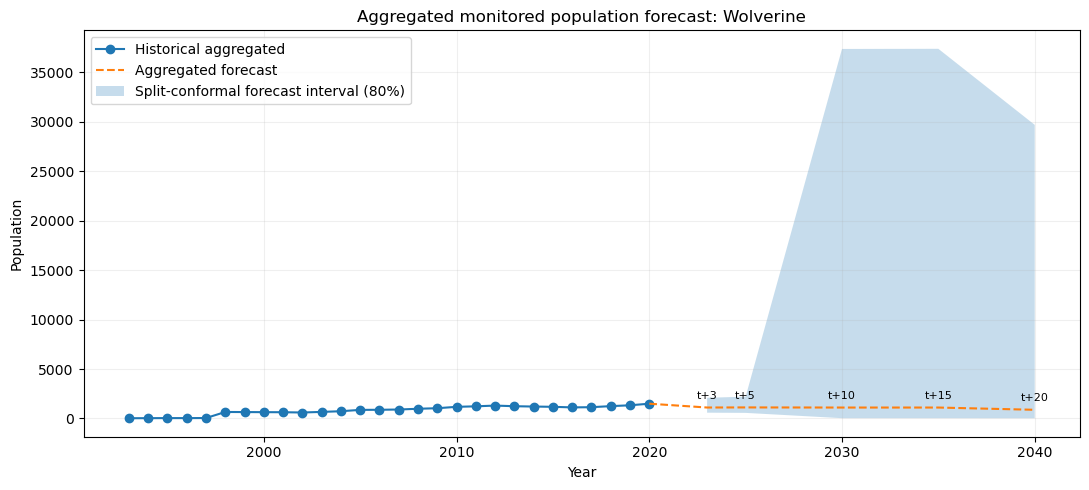

In [10]:
agg_forecast = agg_forecast.sort_values("target_year").copy()

last_hist_point = agg_series.tail(1)[["Year", "Population"]].rename(
    columns={"Year": "target_year", "Population": "prediction"}
)

forecast_line = pd.concat(
    [last_hist_point, agg_forecast[["target_year", "prediction"]]],
    ignore_index=True
)

plt.figure(figsize=(11, 5))

plt.plot(
    agg_series["Year"],
    agg_series["Population"],
    label="Historical aggregated",
    marker="o"
)

plt.plot(
    forecast_line["target_year"],
    forecast_line["prediction"],
    label="Aggregated forecast",
    linestyle="--"
)

plt.fill_between(
    agg_forecast["target_year"].astype(float),
    agg_forecast["lower"].astype(float),
    agg_forecast["upper"].astype(float),
    alpha=0.25,
    label="Split-conformal forecast interval (80%)"
)

for _, row in agg_forecast.iterrows():
    plt.annotate(
        f"t+{int(row['horizon'])}",
        (row["target_year"], row["prediction"]),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

plt.title(f"Aggregated monitored population forecast: {selected_species}")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


**Result summary:**  
This is the recommended primary chart for the frontend: one clean species-level trend with widening uncertainty.


## 11. Visualize the country breakdown forecast

This cell plots the country drill-down view. The historical country line is based on one country-level aggregate per species and year, so it no longer shows artificial spikes caused by several monitoring sites being interleaved into one pseudo-series.

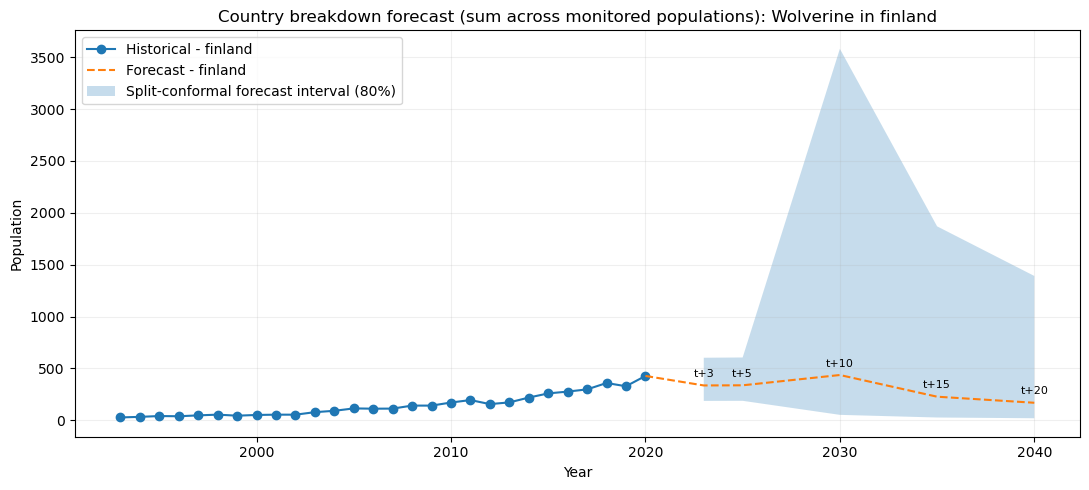

In [12]:
country_forecast = country_forecast.sort_values("target_year").copy()

last_hist_point = country_series.tail(1)[["Year", "Population"]].rename(
    columns={"Year": "target_year", "Population": "prediction"}
)

forecast_line = pd.concat(
    [last_hist_point, country_forecast[["target_year", "prediction"]]],
    ignore_index=True
)

plt.figure(figsize=(11, 5))

plt.plot(
    country_series["Year"],
    country_series["Population"],
    label=f"Historical - {default_country}",
    marker="o"
)

plt.plot(
    forecast_line["target_year"],
    forecast_line["prediction"],
    label=f"Forecast - {default_country}",
    linestyle="--"
)

plt.fill_between(
    country_forecast["target_year"].astype(float),
    country_forecast["lower"].astype(float),
    country_forecast["upper"].astype(float),
    alpha=0.25,
    label="Split-conformal forecast interval (80%)"
)

for _, row in country_forecast.iterrows():
    plt.annotate(
        f"t+{int(row['horizon'])}",
        (row["target_year"], row["prediction"]),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

plt.title(f"Country breakdown forecast (sum across monitored populations): {selected_species} in {default_country}")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Result summary:**  
This is the recommended secondary chart for the frontend: one country-specific forecast for the selected species.


## 12. Prepare frontend-ready outputs

This cell reshapes the historical and forecasted values into API-style tables for a frontend. It preserves metadata such as the aggregation type, forecast horizon, interval level, and uncertainty method so the product layer can render both the main chart and the country drill-down consistently.

In [13]:
frontend_aggregated_history = (
    agg_series[["common_name", "Year", "Population", "aggregate_type", "n_populations"]]
    .copy()
    .rename(columns={"Year": "year", "Population": "population"})
)

frontend_aggregated_history["series_level"] = "aggregated"
frontend_aggregated_history["type"] = "historical"

frontend_aggregated_forecast = (
    agg_forecast.copy()
    .rename(columns={
        "target_year": "year",
        "prediction": "population",
        "lower": "lower_bound",
        "upper": "upper_bound"
    })
)

frontend_aggregated_forecast["series_level"] = "aggregated"
frontend_aggregated_forecast["type"] = "forecast"
frontend_aggregated_forecast["aggregate_type"] = agg_series["aggregate_type"].iloc[0]
frontend_aggregated_forecast["n_populations"] = int(agg_series["n_populations"].iloc[-1])

frontend_country_history = (
    country_series[["common_name", "country", "Year", "Population", "aggregate_type", "n_component_populations"]]
    .copy()
    .rename(columns={"Year": "year", "Population": "population"})
)

frontend_country_history["series_level"] = "country"
frontend_country_history["type"] = "historical"

frontend_country_forecast = (
    country_forecast.copy()
    .rename(columns={
        "target_year": "year",
        "prediction": "population",
        "lower": "lower_bound",
        "upper": "upper_bound"
    })
)

frontend_country_forecast["series_level"] = "country"
frontend_country_forecast["type"] = "forecast"
frontend_country_forecast["aggregate_type"] = country_series["aggregate_type"].iloc[0]
frontend_country_forecast["n_component_populations"] = int(country_series["n_component_populations"].iloc[-1])

available_countries_df = pd.DataFrame({
    "common_name": [selected_species] * len(available_countries),
    "country": available_countries
})

frontend_aggregated_history = frontend_aggregated_history[
    [
        "common_name",
        "series_level",
        "type",
        "aggregate_type",
        "n_populations",
        "year",
        "population"
    ]
]

frontend_aggregated_forecast = frontend_aggregated_forecast[
    [
        "common_name",
        "country",
        "series_level",
        "type",
        "aggregate_type",
        "n_populations",
        "forecast_from_year",
        "year",
        "horizon",
        "population",
        "lower_bound",
        "upper_bound",
        "interval_level",
        "interval_type",
        "conformal_half_width_log"
    ]
]

frontend_country_history = frontend_country_history[
    ["common_name", "country", "series_level", "type", "aggregate_type", "n_component_populations", "year", "population"]
]

frontend_country_forecast = frontend_country_forecast[
    [
        "common_name",
        "country",
        "series_level",
        "type",
        "aggregate_type",
        "n_component_populations",
        "forecast_from_year",
        "year",
        "horizon",
        "population",
        "lower_bound",
        "upper_bound",
        "interval_level",
        "interval_type",
        "conformal_half_width_log"
    ]
]

frontend_aggregated_history.tail(), frontend_aggregated_forecast, frontend_country_forecast

(    common_name series_level        type   aggregate_type  n_populations  \
 204   Wolverine   aggregated  historical  species_raw_sum              4   
 205   Wolverine   aggregated  historical  species_raw_sum              4   
 206   Wolverine   aggregated  historical  species_raw_sum              4   
 207   Wolverine   aggregated  historical  species_raw_sum              4   
 208   Wolverine   aggregated  historical  species_raw_sum              4   
 
      year  population  
 204  2016   1121.6645  
 205  2017   1143.0284  
 206  2018   1249.4700  
 207  2019   1335.2159  
 208  2020   1496.4725  ,
   common_name country series_level      type   aggregate_type  n_populations  \
 0   Wolverine    None   aggregated  forecast  species_raw_sum              4   
 1   Wolverine    None   aggregated  forecast  species_raw_sum              4   
 2   Wolverine    None   aggregated  forecast  species_raw_sum              4   
 3   Wolverine    None   aggregated  forecast  species_raw_su

Recommended frontend API logic:
1. user searches a species
2. backend returns:
   - aggregated history
   - aggregated forecast
   - available countries
   - one default country forecast
3. frontend shows:
   - aggregated chart first
   - optional country dropdown for drill-down


## 13. Final interpretation

### What this notebook now produces

This notebook builds a forecasting pipeline for biodiversity trend exploration with two complementary views:

- an **aggregated species-level forecast** for the main product chart
- a **country-level breakdown forecast** for transparency and drill-down analysis

The output is designed for a frontend or API layer rather than only for notebook inspection. Historical values and future forecasts are returned separately, and the forecast records include uncertainty metadata, horizon information, and aggregation labels.

---

### Why the product uses an aggregated main view plus a country breakdown

The main chart should answer the first user question quickly: **what does the overall monitored trend for this species look like?** That is why the notebook keeps an aggregated species-level series for the default view. It reduces visual clutter and gives a single interpretable entry point.

At the same time, biodiversity data is inherently heterogeneous across locations. Different countries can move in different directions, and users may want to understand whether the aggregate is driven by one region or shared broadly. That is why the notebook also builds a **country view**. The country chart acts as an explanation layer beneath the aggregate.

This two-layer design is a product compromise:

- the aggregate supports clarity and emotional impact
- the country view supports transparency and interpretability

---

### Why the aggregated series is kept in absolute numbers

The aggregated species chart is intentionally kept in **absolute monitored population values** using a raw sum over monitored populations. This was chosen because absolute values are often more intuitive to users than a relative index. A decline toward zero communicates collapse much more directly than an abstract normalized scale.

However, the correct interpretation is important. The chart should be read as:

> **aggregated monitored population in the available dataset**

not as a full global census of the species, and not as a literal species extinction estimate.

This choice was kept because it is strong for user communication, but it should be labeled carefully in the frontend.

---

### Why the country series is aggregated before modeling

A critical issue in the earlier iterations was that a single country could contain multiple monitored populations or locations. If those separate population records were treated as one time series without aggregation, the historical line could alternate sharply from one local population to another, producing an artificial zig-zag pattern.

To fix that, this notebook now aggregates the country-level data to:

> **one species-country-year value**

by summing all monitored populations for that species and country in the same year.

This means the country chart is now a true country-level trend rather than a mixture of several location-level series. The trade-off is that within-country heterogeneity is compressed into one line, but the result is much more interpretable and much more suitable for a product drill-down chart.

---

### Why the forecast uses direct multi-horizon models instead of recursive forecasting

The notebook uses **direct multi-step forecasting**. Separate models are trained for horizons such as t+3, t+5, t+10, t+15, and t+20.

This was chosen instead of recursive forecasting because recursive methods feed earlier predictions back into the model as if they were observed values. That can accumulate error quickly, especially for noisy ecological data and long horizons.

Direct modeling has several advantages here:

- it avoids compounding forecast errors step by step
- it allows each horizon to learn its own error structure
- it produces frontend-friendly horizon anchors directly
- it is easier to explain in a product context

The downside is that direct forecasting does not create a native annual path between the modeled points. If a continuous line is shown in the frontend, it should be understood as a display choice between explicitly modeled horizon anchors.

---

### Why the notebook uses split-conformal uncertainty bands

The uncertainty bands are built with a **split-conformal** approach. For each forecast horizon, the notebook:

1. trains the model on an earlier temporal block
2. predicts on a later calibration block
3. stores the absolute calibration residuals on the log scale
4. uses a quantile of those residuals to form the forecast interval

This was chosen because it gives a more defensible interpretation than a simple heuristic residual standard deviation. The interval width is tied to the empirical errors observed on held-out calibration data.

This approach was also chosen because it works with the existing Random Forest pipeline without requiring a specialized probabilistic model.

To keep the frontend visually coherent, the interval widths are forced to be non-decreasing with horizon. That is a presentation-oriented choice layered on top of the conformal logic.

---

### What the uncertainty bands mean

The uncertainty bands should be interpreted as **empirical forecast intervals derived from past calibration errors**, not as full probabilistic statements about all ecological uncertainty.

They reflect uncertainty captured by the model and calibration setup, but they do not account for every source of future change, such as regime shifts, new conservation policies, land-use shocks, or climate disruptions that are not represented in the historical features.

---

### Main limitations of the modeling approach

#### 1. The forecasts reflect monitored populations, not the full true species population
The dataset covers monitored populations rather than a complete census of all individuals. As a result, the aggregate is informative but not equivalent to a full species abundance estimate.

#### 2. Aggregation still hides some local structure
The species aggregate hides geographic divergence, and the country aggregate hides variation across local monitoring sites within a country.

#### 3. The model is mostly backward-looking
The strongest features are lags and recent temporal summaries. That means the model is good at extrapolating recent structure, but it is not a mechanistic representation of ecological processes.

#### 4. Long-horizon forecasts are fragile
Even with direct modeling, 10 to 20 year forecasts are much less certain than near-term horizons. They should be presented as directional projections rather than precise long-run estimates.

#### 5. External drivers are not yet included
Climate, land use, conservation interventions, habitat quality, and human pressure are not yet modeled explicitly. That limits ecological interpretability and responsiveness to future structural change.

#### 6. Split-conformal intervals are only as good as the calibration setup
Conformal intervals are stronger than heuristic bands, but they still depend on the relevance of the calibration residuals. If the future differs sharply from the calibration period, real errors may be larger.
